In [2]:
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "credit_default_features.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

df.head()

Dataset shape: (30000, 38)
Missing values: 1071


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,HAS_DELAY,RECENT_DELAY,AVG_BILL_AMT,AVG_PAY_AMT,TOTAL_BILL_AMT,TOTAL_PAY_AMT,CREDIT_UTILIZATION,PAYMENT_TO_BILL,BILL_TREND,PAYMENT_TREND
0,1,20000,2,2,1,24,2,2,-1,-1,...,1,2,1284.000000,114.833333,7704,689,0.064200,0.089434,3913,0
1,2,120000,2,2,2,26,-1,2,0,0,...,1,0,2846.166667,833.333333,17077,5000,0.023718,0.292791,-579,-2000
2,3,90000,2,2,2,34,0,0,0,0,...,0,0,16942.166667,1836.333333,101653,11018,0.188246,0.108388,13690,-3482
3,4,50000,2,2,1,37,0,0,0,0,...,0,0,38555.666667,1398.000000,231334,8388,0.771113,0.036259,17443,1000
4,5,50000,1,2,1,57,-1,0,-1,0,...,0,0,18223.166667,9841.500000,109339,59049,0.364463,0.540054,-10514,1321


In [3]:
# =========================================
# DEFINE TARGET AND MODEL FEATURES
# =========================================

TARGET = "TARGET"
ID_COL = "ID"

# Giữ ID riêng để sau này nối prediction trở lại khách hàng
customer_ids = df[ID_COL].copy()

# Target
y = df[TARGET].copy()

# Không dùng ID và các biến demographic đã quyết định loại khỏi primary model
excluded_cols = [
    "ID",
    "TARGET",
    "SEX",
    "AGE",
    "MARRIAGE"
]

X = df.drop(columns=excluded_cols).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nNumber of model features:", X.shape[1])
print("\nModel features:")
for i, col in enumerate(X.columns, start=1):
    print(f"{i:02d}. {col}")

X shape: (30000, 33)
y shape: (30000,)

Target distribution:
TARGET
0    23364
1     6636
Name: count, dtype: int64

Number of model features: 33

Model features:
01. LIMIT_BAL
02. EDUCATION
03. PAY_0
04. PAY_2
05. PAY_3
06. PAY_4
07. PAY_5
08. PAY_6
09. BILL_AMT1
10. BILL_AMT2
11. BILL_AMT3
12. BILL_AMT4
13. BILL_AMT5
14. BILL_AMT6
15. PAY_AMT1
16. PAY_AMT2
17. PAY_AMT3
18. PAY_AMT4
19. PAY_AMT5
20. PAY_AMT6
21. DELAYED_MONTHS
22. MAX_DELAY
23. AVG_DELAY
24. HAS_DELAY
25. RECENT_DELAY
26. AVG_BILL_AMT
27. AVG_PAY_AMT
28. TOTAL_BILL_AMT
29. TOTAL_PAY_AMT
30. CREDIT_UTILIZATION
31. PAYMENT_TO_BILL
32. BILL_TREND
33. PAYMENT_TREND


In [4]:
# =========================================
# TRAIN / VALIDATION / TEST SPLIT
# =========================================

# Bước 1: giữ lại 30% cho validation + test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Bước 2: chia 30% còn lại thành 15% validation + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (21000, 33) (21000,)
Validation: (4500, 33) (4500,)
Test: (4500, 33) (4500,)


In [5]:
def default_rate(y_data):
    return round(y_data.mean() * 100, 2)

print("Full Default Rate:", default_rate(y), "%")
print("Train Default Rate:", default_rate(y_train), "%")
print("Validation Default Rate:", default_rate(y_val), "%")
print("Test Default Rate:", default_rate(y_test), "%")

Full Default Rate: 22.12 %
Train Default Rate: 22.12 %
Validation Default Rate: 22.11 %
Test Default Rate: 22.13 %


In [6]:
categorical_features = [
    "EDUCATION"
]

numerical_features = [
    col
    for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:")
print(len(numerical_features))

Categorical features:
['EDUCATION']

Number of numerical features:
32


In [8]:
# =========================================
# PREPROCESSING
# =========================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            RobustScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numerical_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [9]:
# =========================================
# LOGISTIC REGRESSION BASELINE
# =========================================

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            logistic_model
        )
    ]
)

print("Logistic Regression pipeline created.")

Logistic Regression pipeline created.


In [10]:
logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [11]:
# =========================================
# TRAIN LOGISTIC REGRESSION
# =========================================

logistic_pipeline.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [12]:
# =========================================
# VALIDATION PREDICTIONS
# =========================================

# Xác suất khách hàng default
val_probability = logistic_pipeline.predict_proba(
    X_val
)[:, 1]

# Dự đoán class theo threshold mặc định 0.50
val_prediction = logistic_pipeline.predict(
    X_val
)

validation_results = pd.DataFrame({
    "Actual_Default": y_val.reset_index(drop=True),
    "Probability_of_Default": val_probability,
    "Predicted_Class": val_prediction
})

validation_results.head(10)

,Actual_Default,Probability_of_Default,Predicted_Class
0,0,0.136204,0
1,1,0.188313,0
2,0,0.352563,0
3,0,0.082164,0
4,0,0.075564,0
5,0,0.084127,0
6,0,0.451945,0
7,0,0.121224,0
8,0,0.135413,0
9,0,0.110025,0


In [13]:
# =========================================
# BASELINE VALIDATION METRICS
# =========================================

accuracy = accuracy_score(
    y_val,
    val_prediction
)

precision = precision_score(
    y_val,
    val_prediction
)

recall = recall_score(
    y_val,
    val_prediction
)

f1 = f1_score(
    y_val,
    val_prediction
)

roc_auc = roc_auc_score(
    y_val,
    val_probability
)

pr_auc = average_precision_score(
    y_val,
    val_probability
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

Accuracy : 0.8156
Precision: 0.6542
Recall   : 0.3518
F1 Score : 0.4575
ROC-AUC  : 0.7615
PR-AUC   : 0.5200


In [14]:
# =========================================
# CONFUSION MATRIX
# =========================================

cm = confusion_matrix(
    y_val,
    val_prediction
)

tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

print("\nConfusion Matrix:")
print(cm)

True Negative : 3320
False Positive: 185
False Negative: 645
True Positive : 350

Confusion Matrix:
[[3320  185]
 [ 645  350]]


In [15]:
# =========================================
# THRESHOLD ANALYSIS
# =========================================

thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

threshold_results = []

for threshold in thresholds:

    prediction = (
        val_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        prediction
    )

    recall = recall_score(
        y_val,
        prediction
    )

    f1 = f1_score(
        y_val,
        prediction
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        prediction
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "True_Positive": tp,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Negative": tn
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1,True_Positive,False_Positive,False_Negative,True_Negative
0,0.20,0.4307,0.6151,0.5066,612,809,383,2696
1,0.25,0.4628,0.5819,0.5156,579,672,416,2833
2,0.30,0.5121,0.5116,0.5118,509,485,486,3020
3,0.35,0.5670,0.4633,0.5100,461,352,534,3153
4,0.40,0.5924,0.4251,0.4950,423,291,572,3214
5,0.45,0.6299,0.4020,0.4908,400,235,595,3270
6,0.50,0.6542,0.3518,0.4575,350,185,645,3320


In [17]:
# =========================================
# SELECT WORKING THRESHOLD
# =========================================

BASELINE_THRESHOLD = 0.25

val_prediction_025 = (
    val_probability >= BASELINE_THRESHOLD
).astype(int)

baseline_threshold_metrics = {
    "Model": "Logistic Regression",
    "Threshold": BASELINE_THRESHOLD,
    "Precision": precision_score(
        y_val,
        val_prediction_025
    ),
    "Recall": recall_score(
        y_val,
        val_prediction_025
    ),
    "F1": f1_score(
        y_val,
        val_prediction_025
    ),
    "ROC_AUC": roc_auc_score(
        y_val,
        val_probability
    ),
    "PR_AUC": average_precision_score(
        y_val,
        val_probability
    )
}

pd.DataFrame(
    [baseline_threshold_metrics]
).round(4)

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.25,0.4628,0.5819,0.5156,0.7615,0.52


## Logistic Regression Baseline

The Logistic Regression baseline achieved:

- ROC-AUC: 0.7615
- PR-AUC: 0.5200
- Default threshold (0.50) recall: 35.18%

The default 0.50 threshold missed a large proportion of actual default customers.

Threshold analysis showed that lowering the classification threshold improved default detection.

A working threshold of **0.25** was selected for the baseline model because:

- Recall increased to 58.19%
- False negatives decreased from 645 to 416
- F1 increased from 0.4575 to 0.5156
- Precision remained at 46.28%

This threshold is used as a project baseline rather than a real-world lending policy threshold. A production threshold would require explicit business costs for false positives and false negatives.   

In [18]:
from xgboost import XGBClassifier

# Tính tỷ lệ Non-default / Default trong training set
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-default:", negative_count)
print("Default:", positive_count)
print("scale_pos_weight:", round(scale_pos_weight, 3))

Non-default: 16355
Default: 4645
scale_pos_weight: 3.521


In [19]:
# =========================================
# XGBOOST CHALLENGER MODEL
# =========================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

print("XGBoost pipeline created.")

XGBoost pipeline created.


In [20]:
# Train XGBoost only on training data

xgb_pipeline.fit(
    X_train,
    y_train
)

print("XGBoost training completed.")

XGBoost training completed.


In [21]:
# XGBoost validation predictions

xgb_val_probability = xgb_pipeline.predict_proba(
    X_val
)[:, 1]

xgb_val_prediction = (
    xgb_val_probability >= 0.50
).astype(int)

pd.DataFrame({
    "Actual_Default": y_val.reset_index(drop=True),
    "XGB_PD": xgb_val_probability,
    "Predicted_Class": xgb_val_prediction
}).head(10)

,Actual_Default,XGB_PD,Predicted_Class
0,0,0.486152,0
1,1,0.633709,1
2,0,0.468818,0
3,0,0.241160,0
4,0,0.386772,0
5,0,0.130755,0
6,0,0.588983,1
7,0,0.333164,0
8,0,0.338514,0
9,0,0.161067,0


In [22]:
xgb_accuracy = accuracy_score(
    y_val,
    xgb_val_prediction
)

xgb_precision = precision_score(
    y_val,
    xgb_val_prediction
)

xgb_recall = recall_score(
    y_val,
    xgb_val_prediction
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_prediction
)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_probability
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_probability
)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")
print(f"PR-AUC   : {xgb_pr_auc:.4f}")

Accuracy : 0.7611
Precision: 0.4697
Recall   : 0.6241
F1 Score : 0.5360
ROC-AUC  : 0.7789
PR-AUC   : 0.5575


In [23]:
# =========================================
# XGBOOST THRESHOLD ANALYSIS
# =========================================

xgb_thresholds = [
    0.20,
    0.25,
    0.30,
    0.35,
    0.40,
    0.45,
    0.50
]

xgb_threshold_results = []

for threshold in xgb_thresholds:

    prediction = (
        xgb_val_probability >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        prediction
    )

    recall = recall_score(
        y_val,
        prediction
    )

    f1 = f1_score(
        y_val,
        prediction
    )

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        prediction
    ).ravel()

    xgb_threshold_results.append({
        "Threshold": threshold,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
        "True_Positive": tp,
        "False_Positive": fp,
        "False_Negative": fn,
        "True_Negative": tn
    })

xgb_threshold_df = pd.DataFrame(
    xgb_threshold_results
)

xgb_threshold_df

,Threshold,Precision,Recall,F1,True_Positive,False_Positive,False_Negative,True_Negative
0,0.20,0.2628,0.9467,0.4114,942,2642,53,863
1,0.25,0.2829,0.9085,0.4314,904,2292,91,1213
2,0.30,0.3119,0.8633,0.4583,859,1895,136,1610
3,0.35,0.3481,0.8141,0.4877,810,1517,185,1988
4,0.40,0.3761,0.7216,0.4945,718,1191,277,2314
5,0.45,0.4263,0.6683,0.5205,665,895,330,2610
6,0.50,0.4697,0.6241,0.5360,621,701,374,2804


In [24]:
best_xgb_row = xgb_threshold_df.loc[
    xgb_threshold_df["F1"].idxmax()
]

best_xgb_row

Threshold            0.5000
Precision            0.4697
Recall               0.6241
F1                   0.5360
True_Positive      621.0000
False_Positive     701.0000
False_Negative     374.0000
True_Negative     2804.0000
Name: 6, dtype: float64

In [25]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "Threshold": 0.25,
        "Precision": 0.4628,
        "Recall": 0.5819,
        "F1": 0.5156
    },
    {
        "Model": "XGBoost",
        "ROC_AUC": xgb_roc_auc,
        "PR_AUC": xgb_pr_auc,
        "Threshold": best_xgb_row["Threshold"],
        "Precision": best_xgb_row["Precision"],
        "Recall": best_xgb_row["Recall"],
        "F1": best_xgb_row["F1"]
    }
])

model_comparison.round(4)

,Model,ROC_AUC,PR_AUC,Threshold,Precision,Recall,F1
0,Logistic Regression,0.7615,0.5200,0.25,0.4628,0.5819,0.5156
1,XGBoost,0.7789,0.5575,0.50,0.4697,0.6241,0.5360


In [27]:
import matplotlib.pyplot as plt

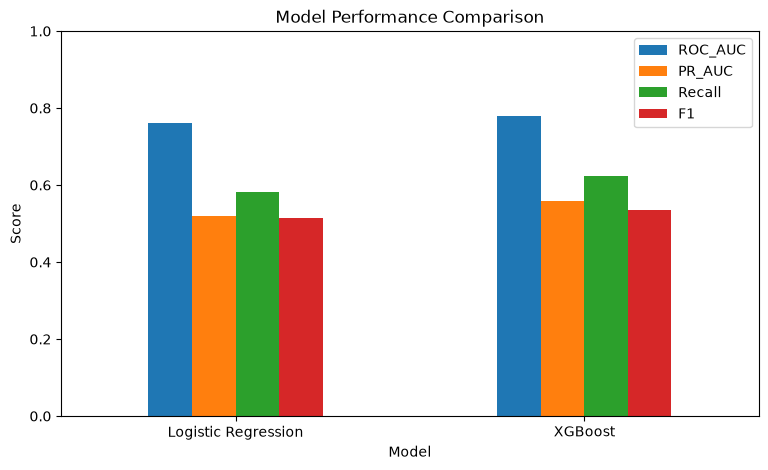

In [28]:
comparison_plot = model_comparison.set_index("Model")[
    ["ROC_AUC", "PR_AUC", "Recall", "F1"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.show()

In [29]:
model_comparison.round(4)

,Model,ROC_AUC,PR_AUC,Threshold,Precision,Recall,F1
0,Logistic Regression,0.7615,0.5200,0.25,0.4628,0.5819,0.5156
1,XGBoost,0.7789,0.5575,0.50,0.4697,0.6241,0.5360


In [30]:
best_xgb_row

Threshold            0.5000
Precision            0.4697
Recall               0.6241
F1                   0.5360
True_Positive      621.0000
False_Positive     701.0000
False_Negative     374.0000
True_Negative     2804.0000
Name: 6, dtype: float64

In [31]:
BEST_XGB_THRESHOLD = float(
    best_xgb_row["Threshold"]
)

xgb_best_prediction = (
    xgb_val_probability >= BEST_XGB_THRESHOLD
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    xgb_best_prediction
).ravel()

print("Best XGBoost Threshold:", BEST_XGB_THRESHOLD)
print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

Best XGBoost Threshold: 0.5
True Negative : 2804
False Positive: 701
False Negative: 374
True Positive : 621


In [32]:
# =========================================
# FINAL TEST EVALUATION - XGBOOST
# =========================================

test_probability = xgb_pipeline.predict_proba(
    X_test
)[:, 1]

test_prediction = (
    test_probability >= BEST_XGB_THRESHOLD
).astype(int)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

test_precision = precision_score(
    y_test,
    test_prediction
)

test_recall = recall_score(
    y_test,
    test_prediction
)

test_f1 = f1_score(
    y_test,
    test_prediction
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probability
)

test_pr_auc = average_precision_score(
    y_test,
    test_probability
)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")

Accuracy : 0.7527
Precision: 0.4571
Recall   : 0.6255
F1 Score : 0.5282
ROC-AUC  : 0.7799
PR-AUC   : 0.5567


In [33]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_prediction
).ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 2764
False Positive: 740
False Negative: 373
True Positive : 623


## Final XGBoost Test Performance

The selected XGBoost model was evaluated once on the held-out test set after model and threshold selection.

### Test metrics

- Accuracy: 75.27%
- Precision: 45.71%
- Recall: 62.55%
- F1 Score: 52.82%
- ROC-AUC: 0.7799
- PR-AUC: 0.5567

### Confusion Matrix

- True Negative: 2,764
- False Positive: 740
- False Negative: 373
- True Positive: 623

The model detected 623 of 996 actual default customers in the test set, corresponding to a recall of 62.55%.

XGBoost was selected as the champion classification model because it provided stronger default detection and ranking performance than the Logistic Regression baseline.

The raw XGBoost probability output will be calibrated before being interpreted as Probability of Default (PD).

In [34]:
from sklearn.calibration import CalibratedClassifierCV

In [35]:
calibrated_xgb = CalibratedClassifierCV(
    estimator=xgb_pipeline,
    method="sigmoid",
    cv=3
)

print("Calibrated XGBoost created.")

Calibrated XGBoost created.


In [36]:
calibrated_xgb.fit(
    X_train,
    y_train
)

print("Probability calibration completed.")

Probability calibration completed.


In [37]:
calibrated_val_probability = calibrated_xgb.predict_proba(
    X_val
)[:, 1]

pd.DataFrame({
    "Uncalibrated_XGB": xgb_val_probability,
    "Calibrated_PD": calibrated_val_probability,
    "Actual_Default": y_val.reset_index(drop=True)
}).head(10)

,Uncalibrated_XGB,Calibrated_PD,Actual_Default
0,0.486152,0.223893,0
1,0.633709,0.366983,1
2,0.468818,0.237999,0
3,0.241160,0.066597,0
4,0.386772,0.161223,0
5,0.130755,0.059253,0
6,0.588983,0.318087,0
7,0.333164,0.110598,0
8,0.338514,0.130613,0
9,0.161067,0.065658,0


In [38]:
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

In [39]:
# =========================================
# CALIBRATION QUALITY CHECK
# =========================================

uncalibrated_brier = brier_score_loss(
    y_val,
    xgb_val_probability
)

calibrated_brier = brier_score_loss(
    y_val,
    calibrated_val_probability
)

uncalibrated_logloss = log_loss(
    y_val,
    xgb_val_probability
)

calibrated_logloss = log_loss(
    y_val,
    calibrated_val_probability
)

print("Brier Score")
print(f"Uncalibrated: {uncalibrated_brier:.4f}")
print(f"Calibrated  : {calibrated_brier:.4f}")

print("\nLog Loss")
print(f"Uncalibrated: {uncalibrated_logloss:.4f}")
print(f"Calibrated  : {calibrated_logloss:.4f}")

Brier Score
Uncalibrated: 0.1767
Calibrated  : 0.1359

Log Loss
Uncalibrated: 0.5359
Calibrated  : 0.4319


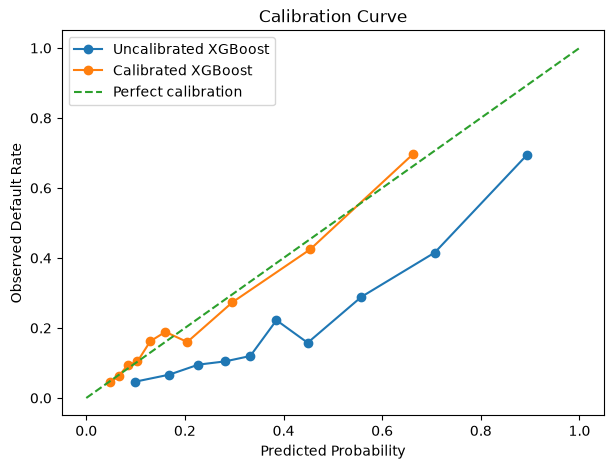

In [40]:
prob_true_raw, prob_pred_raw = calibration_curve(
    y_val,
    xgb_val_probability,
    n_bins=10,
    strategy="quantile"
)

prob_true_cal, prob_pred_cal = calibration_curve(
    y_val,
    calibrated_val_probability,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred_raw,
    prob_true_raw,
    marker="o",
    label="Uncalibrated XGBoost"
)

plt.plot(
    prob_pred_cal,
    prob_true_cal,
    marker="o",
    label="Calibrated XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.title("Calibration Curve")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.legend()

plt.show()

In [41]:
calibrated_roc_auc = roc_auc_score(
    y_val,
    calibrated_val_probability
)

calibrated_pr_auc = average_precision_score(
    y_val,
    calibrated_val_probability
)

print(f"Calibrated ROC-AUC: {calibrated_roc_auc:.4f}")
print(f"Calibrated PR-AUC : {calibrated_pr_auc:.4f}")

Calibrated ROC-AUC: 0.7788
Calibrated PR-AUC : 0.5553


In [42]:
# =========================================
# CALIBRATED PD ON TEST SET
# =========================================

calibrated_test_probability = calibrated_xgb.predict_proba(
    X_test
)[:, 1]

test_pd_summary = pd.Series(
    calibrated_test_probability
).describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

test_pd_summary

count    4500.000000
mean        0.220911
std         0.190276
min         0.035938
10%         0.057700
25%         0.081774
50%         0.143192
75%         0.296286
90%         0.581293
95%         0.668331
99%         0.703631
max         0.728523
dtype: float64

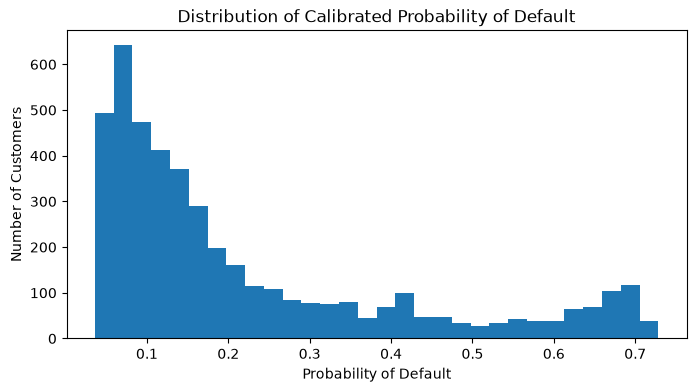

In [43]:
plt.figure(figsize=(8, 4))

plt.hist(
    calibrated_test_probability,
    bins=30
)

plt.title("Distribution of Calibrated Probability of Default")
plt.xlabel("Probability of Default")
plt.ylabel("Number of Customers")

plt.show()

In [44]:
def assign_risk_band(pd_value):
    if pd_value < 0.10:
        return "Low"
    elif pd_value < 0.25:
        return "Medium"
    else:
        return "High"

In [45]:
test_risk_band = pd.Series(
    calibrated_test_probability
).apply(assign_risk_band)

test_risk_band.value_counts()

Medium    1696
Low       1493
High      1311
Name: count, dtype: int64

In [46]:
risk_validation = pd.DataFrame({
    "PD": calibrated_test_probability,
    "Risk_Band": test_risk_band,
    "Actual_Default": y_test.reset_index(drop=True)
})

risk_band_summary = (
    risk_validation
    .groupby("Risk_Band")["Actual_Default"]
    .agg(
        Customers="count",
        Defaults="sum",
        Default_Rate="mean"
    )
)

risk_band_summary["Default_Rate"] = (
    risk_band_summary["Default_Rate"] * 100
).round(2)

risk_band_summary

,Customers,Defaults,Default_Rate
Risk_Band,,,
High,1311,618,47.14
Low,1493,106,7.10
Medium,1696,272,16.04


In [47]:
test_risk_score = np.round(
    (1 - calibrated_test_probability) * 100,
    0
).astype(int)

In [48]:
pd.DataFrame({
    "PD": calibrated_test_probability,
    "Risk_Score": test_risk_score,
    "Risk_Band": test_risk_band
}).head(10)

,PD,Risk_Score,Risk_Band
0,0.055322,94,Low
1,0.054845,95,Low
2,0.627280,37,High
3,0.232609,77,Medium
4,0.687629,31,High
5,0.293594,71,High
6,0.161102,84,Medium
7,0.055322,94,Low
8,0.523178,48,High
9,0.058670,94,Low


In [49]:
test_customer_ids = df.loc[
    X_test.index,
    "ID"
].reset_index(drop=True)

In [50]:
customer_risk_table = pd.DataFrame({
    "Customer_ID": test_customer_ids,
    "Actual_Default": y_test.reset_index(drop=True),
    "Probability_of_Default": calibrated_test_probability,
    "Risk_Score": test_risk_score,
    "Risk_Band": test_risk_band
})

customer_risk_table.head(10)

,Customer_ID,Actual_Default,Probability_of_Default,Risk_Score,Risk_Band
0,25872,0,0.055322,94,Low
1,26119,0,0.054845,95,Low
2,15425,1,0.627280,37,High
3,23109,0,0.232609,77,Medium
4,1638,0,0.687629,31,High
5,27350,0,0.293594,71,High
6,19997,1,0.161102,84,Medium
7,12687,0,0.055322,94,Low
8,4190,0,0.523178,48,High
9,27426,1,0.058670,94,Low


In [51]:
RISK_OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "customer_risk_scores.csv"
)

customer_risk_table.to_csv(
    RISK_OUTPUT_PATH,
    index=False
)

print("Risk score file saved:")
print(RISK_OUTPUT_PATH)

print("\nShape:", customer_risk_table.shape)

Risk score file saved:
h:\Credit_Risk_Modeling\data\processed\customer_risk_scores.csv

Shape: (4500, 5)


In [52]:
import joblib

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Raw XGBoost champion classifier
joblib.dump(
    xgb_pipeline,
    MODEL_DIR / "xgboost_champion.pkl"
)

# Calibrated model used for PD
joblib.dump(
    calibrated_xgb,
    MODEL_DIR / "xgboost_calibrated_pd.pkl"
)

print("Models saved successfully.")

Models saved successfully.
